# Day 8 — Preparing Data Visualization I: Charts and Design

### DICT Data Analytics — Train the Trainer · Participant Notebook

**TESDA alignment:** Prepare data visualization

Today we move from the **summaries built on Day 7** to visual evidence. The goal is not decoration. The goal is to choose a chart that answers a stated question, build it correctly, and remove design choices that can mislead the reader.

### Today’s workflow

**QUESTION → CHART TYPE → BUILD → CHECK → INTERPRET**

### How to use this notebook

1. Run **Setup** first.
2. Read each short lecture section before the hands-on task.
3. Complete cells marked `YOUR CODE HERE`.
4. Run the checker after each hands-on section.
5. Keep your charts visible for the instructor-led discussion.
6. When a chart looks attractive but makes the question harder to answer, simplify it.


## Setup

Colab runtimes can reset. If your variables disappear, rerun this cell.

This standalone notebook recreates the same deterministic course files used in the 10-day program, including the versioned cleaned dataset from Day 5.

**Files created:**
- `data/service_requests_clean_v1.csv` — cleaned 2025 service requests
- `data/regional_offices.json` — nested master data for nine field offices


In [34]:
# ============================================================
# SETUP — run this cell first, every session.
# This creates the same course dataset used across the 10-day program.
# It also creates the Day 7 clean v1 file used for summarization.
# ============================================================
import pandas as pd, numpy as np, json, random, os

np.random.seed(2026)
random.seed(2026)
os.makedirs("data", exist_ok=True)

REGIONS = ["NCR", "Region III", "Region IV-A", "Region VI", "Region VII", "Region XI"]
OFFICES = {
    "NCR": ["DICT-NCR-01", "DICT-NCR-02"],
    "Region III": ["DICT-R3-01"],
    "Region IV-A": ["DICT-R4A-01", "DICT-R4A-02"],
    "Region VI": ["DICT-R6-01"],
    "Region VII": ["DICT-R7-01", "DICT-R7-02"],
    "Region XI": ["DICT-R11-01"],
}
SERVICES = [
    "Free WiFi Installation", "Digital Literacy Training",
    "Business Permit Assistance", "ICT Equipment Request",
    "Cybersecurity Advisory", "eGov App Support",
]
CHANNELS = ["Walk-in", "Online Portal", "Email", "Hotline", "Mobile App"]
STATUS = ["Resolved", "Pending", "Escalated", "Closed - No Action"]
AGE_GROUPS = ["18-24", "25-34", "35-44", "45-54", "55+"]

dates = pd.date_range("2025-01-01", "2025-12-31", freq="D")
rows = []
for i in range(1, 1201):
    region = random.choice(REGIONS)
    status = random.choices(STATUS, weights=[62, 20, 12, 6])[0]
    rows.append({
        "request_id": f"SR-2025-{i:05d}",
        "date_filed": random.choice(dates),
        "region": region,
        "office_code": random.choice(OFFICES[region]),
        "service_type": random.choice(SERVICES),
        "channel": random.choices(CHANNELS, weights=[30, 25, 15, 15, 15])[0],
        "status": status,
        "days_to_resolve": (
            max(0, int(np.random.lognormal(1.6, 0.75)))
            if status in ("Resolved", "Closed - No Action") else np.nan
        ),
        "satisfaction_rating": (
            random.choice([1, 2, 3, 4, 5]) if status == "Resolved" else np.nan
        ),
        "citizen_age_group": random.choice(AGE_GROUPS),
        "processing_fee": float(random.choice([0, 0, 0, 50, 100, 150, 200])),
    })

df = pd.DataFrame(rows)

# Deliberate defects used by the cleaning lessons.
d = df.copy()
_ncr = d.index[d["region"] == "NCR"]
d.loc[pd.Index(np.random.RandomState(1).choice(_ncr, 40, replace=False)), "region"] = " ncr "
d.loc[d.sample(25, random_state=2).index, "service_type"] = "Free Wifi Installation"
d.loc[d.sample(30, random_state=3).index, "citizen_age_group"] = np.nan
d.loc[d.sample(18, random_state=4).index, "processing_fee"] = np.nan
d.loc[d.sample(8, random_state=5).index, "days_to_resolve"] = 999
d = pd.concat([d, d.sample(22, random_state=6)])
d["date_filed"] = d["date_filed"].astype(str)
_mix = d.sample(60, random_state=7).index
d.loc[_mix, "date_filed"] = pd.to_datetime(d.loc[_mix, "date_filed"]).dt.strftime("%m/%d/%Y")
d = d.sample(frac=1, random_state=8).reset_index(drop=True)
d.to_csv("data/service_requests.csv", index=False)

# Create the same office master file used by the course.
CITIES = {
    "NCR": "Quezon City", "Region III": "San Fernando",
    "Region IV-A": "Calamba", "Region VI": "Iloilo City",
    "Region VII": "Cebu City", "Region XI": "Davao City",
}
offices = []
for region, codes in OFFICES.items():
    for c_ in codes:
        offices.append({
            "office_code": c_,
            "office_name": f"DICT Field Office {c_.split('-')[-1]} - {region}",
            "location": {
                "region": region,
                "city": CITIES[region],
                "coordinates": {
                    "lat": round(random.uniform(6.0, 16.5), 4),
                    "lon": round(random.uniform(120.0, 126.0), 4),
                },
            },
            "staff_count": random.randint(8, 45),
            "year_established": random.randint(2012, 2022),
            "annual_budget_php": random.randrange(2_000_000, 12_000_000, 250_000),
            "services_offered": random.sample(SERVICES, k=random.randint(3, 6)),
            "is_active": random.random() > 0.1,
        })

with open("data/regional_offices.json", "w") as f:
    json.dump({
        "agency": "Department of Information and Communications Technology",
        "dataset": "Regional Field Office Master Data",
        "as_of": "2025-12-31",
        "record_count": len(offices),
        "offices": offices,
    }, f, indent=2)

# Day 7 uses the versioned clean file created by the course cleaning rules.
clean = d.drop_duplicates().copy()
clean["region"] = clean["region"].str.strip().str.upper()
clean["service_type"] = clean["service_type"].replace(
    {"Free Wifi Installation": "Free WiFi Installation"}
)
clean["date_filed"] = pd.to_datetime(clean["date_filed"], format="mixed")
clean.loc[clean["days_to_resolve"] == 999, "days_to_resolve"] = np.nan
clean.to_csv("data/service_requests_clean_v1.csv", index=False)

print("Setup complete.")
print("Raw rows:", len(d))
print("Clean v1 rows:", len(clean))
print("Files:", sorted(os.listdir("data")))


Setup complete.
Raw rows: 1222
Clean v1 rows: 1200
Files: ['regional_offices.json', 'service_requests.csv', 'service_requests_clean_v1.csv']


## Orientation — Start with the question

Chart choice is not a style decision. It follows from the question.

| Question | First chart to consider |
|---|---|
| How do categories compare? | **Bar** |
| How has something changed over time? | **Line** |
| How are numeric values distributed? | **Histogram or box plot** |
| Do two numeric variables relate? | **Scatter** |
| What makes up a whole? | **Stacked bar** (pie only for 2–3 slices) |

### One sentence test

Before coding, complete:

> “I need to show **_____** so the reader can decide **_____**.”

That sentence should drive the chart type, the ordering, and the title.


# Lecture 1 — Matching the Chart to the Question

## Bar charts — compare categories

A bar chart is the default for comparing separate categories. Sorting by value makes the ranking visible when the order itself is not meaningful.

```python
by_region = clean["region"].value_counts()

plt.bar(by_region.index, by_region.values)
plt.title("Service Requests by Region, 2025")
plt.ylabel("Number of requests")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
```

### Line charts — show change over time

A line chart is useful when the x-axis has a natural sequence such as months. Do not connect unrelated categories just because the chart looks smooth.

```python
monthly = clean.set_index("date_filed").resample("ME").size()

plt.plot(monthly.index, monthly.values, marker="o")
plt.title("Monthly Service Request Volume, 2025")
plt.xlabel("Month")
plt.ylabel("Number of requests")
plt.tight_layout()
plt.show()
```


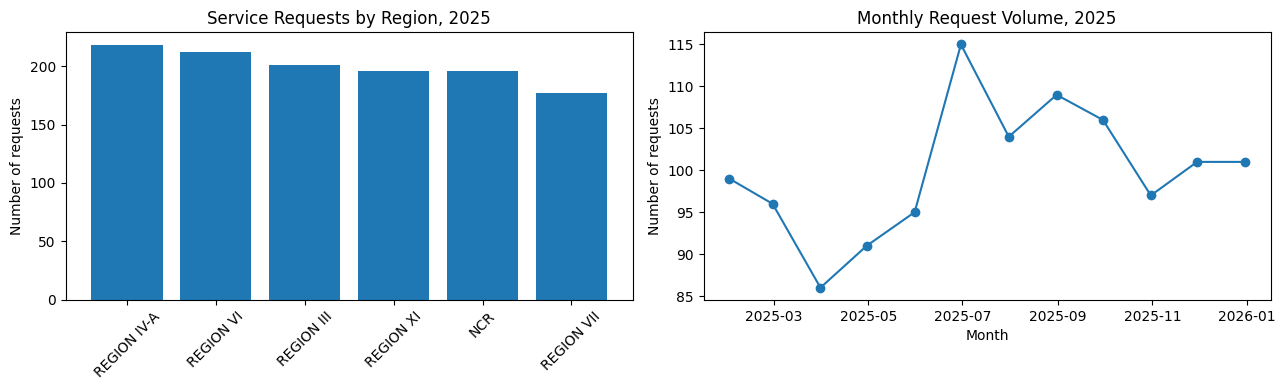

In [35]:
# Lecture 1 demo
import pandas as pd
import matplotlib.pyplot as plt

clean = pd.read_csv("data/service_requests_clean_v1.csv", parse_dates=["date_filed"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

by_region = clean["region"].value_counts()
axes[0].bar(by_region.index, by_region.values)
axes[0].set_title("Service Requests by Region, 2025")
axes[0].set_ylabel("Number of requests")
axes[0].tick_params(axis="x", rotation=45)

monthly = clean.set_index("date_filed").resample("ME").size()
axes[1].plot(monthly.index, monthly.values, marker="o")
axes[1].set_title("Monthly Request Volume, 2025")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Number of requests")

plt.tight_layout()
plt.show()


### Hands-On 1 — Bar and Line · 9:00–10:00

Build both charts from `clean`.

#### Task 1.1 — Requests by service type

Create `by_service` with request counts by `service_type`, sorted from largest to smallest. Display it.

Then create a bar chart using `by_service` with:
- a descriptive title
- a y-axis label
- readable category labels


Requests by Service Type:
service_type
Free WiFi Installation        238
eGov App Support              200
Business Permit Assistance    198
Digital Literacy Training     197
ICT Equipment Request         192
Cybersecurity Advisory        175
Name: count, dtype: int64


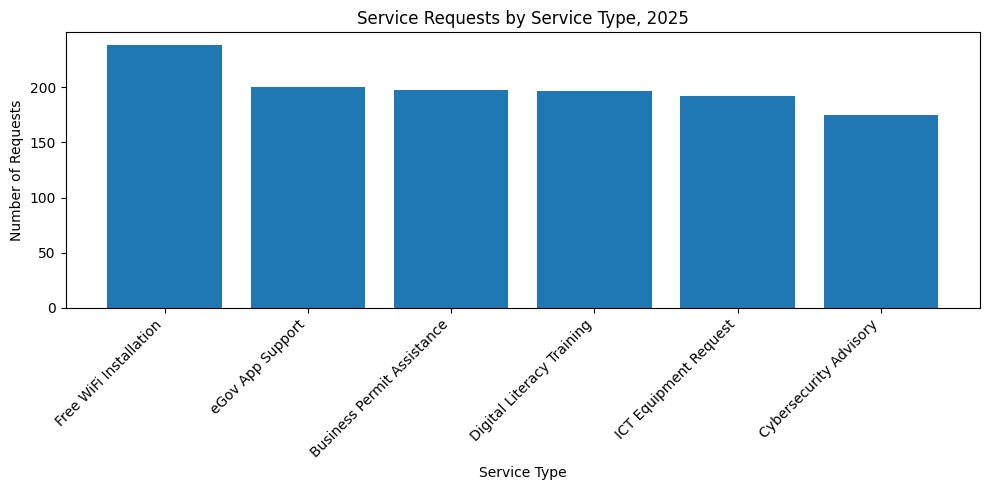

In [36]:
# ============================================================
# HANDS-ON 1 — BAR AND LINE
# Task 1.1 — Requests by Service Type
# ============================================================

# STEP 1 — Import the libraries needed for this task.
# pandas is used for working with the dataset.
# matplotlib.pyplot is used for creating the bar chart.
import pandas as pd
import matplotlib.pyplot as plt


# STEP 2 — Load the cleaned dataset.
# parse_dates converts date_filed into a proper date/time column.
clean = pd.read_csv(
    "data/service_requests_clean_v1.csv",
    parse_dates=["date_filed"]
)


# STEP 3 — Count the number of requests for each service type.
# value_counts() counts how many records belong to each service.
by_service = clean["service_type"].value_counts()


# STEP 4 — Sort the counts from largest to smallest.
# This makes the highest-volume service appear first.
by_service = by_service.sort_values(ascending=False)


# STEP 5 — Display the request counts.
print("Requests by Service Type:")
print(by_service)


# STEP 6 — Create the bar chart.
# figsize controls the width and height of the chart.
plt.figure(figsize=(10, 5))


# STEP 7 — Plot the service types on the x-axis
# and their request counts on the y-axis.
plt.bar(
    by_service.index,
    by_service.values
)


# STEP 8 — Add a descriptive chart title.
plt.title("Service Requests by Service Type, 2025")


# STEP 9 — Add labels to the axes.
plt.xlabel("Service Type")
plt.ylabel("Number of Requests")


# STEP 10 — Rotate the service names.
# This makes the longer category labels easier to read.
plt.xticks(rotation=45, ha="right")


# STEP 11 — Adjust the spacing automatically.
# This prevents labels and titles from being cut off.
plt.tight_layout()


# STEP 12 — Display the completed chart.
plt.show()

#### Task 1.2 — Monthly request volume

Create `monthly_volume` with the number of requests in each month of 2025.

Then create a line chart with:
- a descriptive title
- x-axis label `Month`
- y-axis label `Number of requests`
- markers on the monthly points


Monthly Request Volume:
date_filed
2025-01-31     99
2025-02-28     96
2025-03-31     86
2025-04-30     91
2025-05-31     95
2025-06-30    115
2025-07-31    104
2025-08-31    109
2025-09-30    106
2025-10-31     97
2025-11-30    101
2025-12-31    101
Freq: ME, dtype: int64


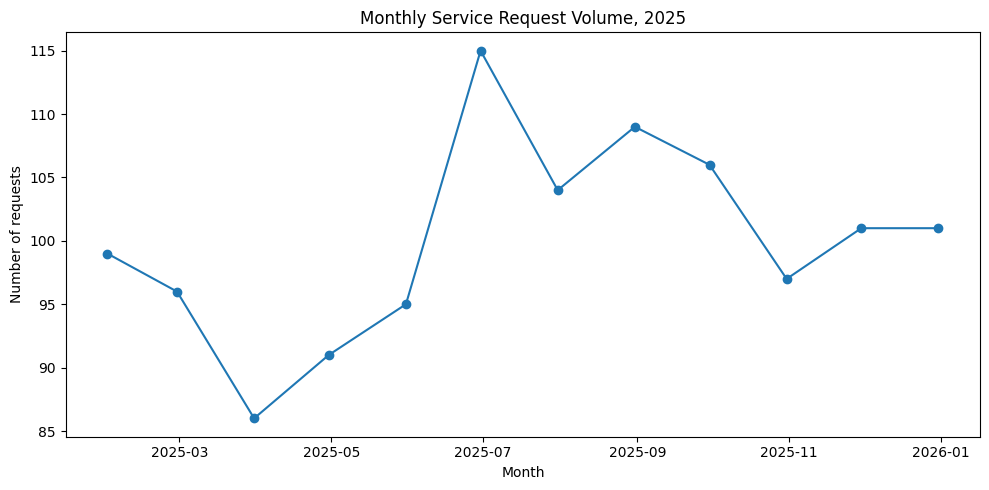

In [37]:
# ============================================================
# HANDS-ON 1 — BAR AND LINE
# Task 1.2 — Monthly Request Volume
# ============================================================

# STEP 1 — Make sure the date_filed column is in date/time format.
# This is necessary because we will group the requests by month.
clean["date_filed"] = pd.to_datetime(clean["date_filed"])


# STEP 2 — Set date_filed as the DataFrame index.
# Resampling by month works with a DatetimeIndex.
clean_by_date = clean.set_index("date_filed")


# STEP 3 — Count the number of requests in each month.
# "ME" means Month End, so the data is grouped by calendar month.
monthly_volume = clean_by_date.resample("ME").size()


# STEP 4 — Display the monthly request volume.
print("Monthly Request Volume:")
print(monthly_volume)


# STEP 5 — Create the line chart.
plt.figure(figsize=(10, 5))


# STEP 6 — Plot the monthly request counts.
# marker="o" places a marker on each monthly data point.
plt.plot(
    monthly_volume.index,
    monthly_volume.values,
    marker="o"
)


# STEP 7 — Add a descriptive chart title.
plt.title("Monthly Service Request Volume, 2025")


# STEP 8 — Add the x-axis label.
plt.xlabel("Month")


# STEP 9 — Add the y-axis label.
plt.ylabel("Number of requests")


# STEP 10 — Adjust the chart spacing.
# This prevents labels and the title from being cut off.
plt.tight_layout()


# STEP 11 — Display the completed line chart.
plt.show()


#### Task 1.3 — Peak month

Create `peak_month` containing the month with the highest request volume.


In [38]:
# ============================================================
# TASK 1.3 — PEAK MONTH
# ============================================================

# STEP 1 — Find the month with the highest number of requests.
# idxmax() returns the index (month) where the highest value occurs.
peak_month = monthly_volume.idxmax()


# STEP 2 — Display the peak month.
print(peak_month)


2025-06-30 00:00:00


#### Task 1.4 — Mark the section complete

Set `chart1_done = True` only after both charts render with titles and labels.


In [39]:
# ============================================================
# TASK 1.4 — MARK THE SECTION COMPLETE
# ============================================================

# STEP 1 — Confirm that both charts have been completed.
# Set chart1_done to True only after:
#   1. The bar chart from Task 1.1 renders correctly.
#   2. The line chart from Task 1.2 renders correctly.
#   3. Both charts have descriptive titles.
#   4. Both charts have appropriate axis labels.
chart1_done = True


# STEP 2 — Display the completion status.
print("Chart 1 complete:", chart1_done)

Chart 1 complete: True


## Check Section 1

The checker validates the requested summaries and peak month. It does not judge artistic choices.


In [40]:
# Section 1 checker

def check_section_1():
    required = ["by_service", "monthly_volume", "peak_month", "chart1_done"]
    missing = [x for x in required if x not in globals() or globals()[x] is None]
    if missing:
        print("Missing:", missing)
        return

    expected_service = clean["service_type"].value_counts().sort_values(ascending=False)
    expected_monthly = clean.set_index("date_filed").resample("ME").size()
    checks = {
        "by_service matches service counts": by_service.equals(expected_service),
        "monthly_volume matches monthly counts": monthly_volume.equals(expected_monthly),
        "peak_month is the max month": peak_month == expected_monthly.idxmax(),
        "chart1_done is True": chart1_done is True,
    }
    for label, ok in checks.items():
        print(("PASS" if ok else "FAIL"), label)

check_section_1()


PASS by_service matches service counts
PASS monthly_volume matches monthly counts
PASS peak_month is the max month
PASS chart1_done is True


# Analysis and Discussion 1

## 1. Is there a real seasonal pattern in the monthly line, or could the variation be ordinary noise?

The monthly line shows how request volume changes across the months of 2025, but variation alone does not prove that a real seasonal pattern exists. A seasonal pattern would require a recurring or consistent pattern, ideally supported by data from multiple years or other evidence. With only one year of monthly data, the observed increases and decreases could simply be ordinary month-to-month variation or random noise.

Therefore, the chart can show a possible pattern worth investigating, but it should not be described as a confirmed seasonal effect based on this dataset alone.

---

## 2. Your bar chart is sorted by volume. When would alphabetical or geographic order be more useful?

Sorting by volume is useful when the purpose is to compare or rank service types from highest to lowest.

Alphabetical order can be more useful when readers need to quickly locate a particular category, especially in a long list where ranking is not the main purpose.

Geographic order can be more useful when the categories represent locations and the reader needs to follow a meaningful geographic sequence, such as grouping regions from north to south or following an established administrative order.

The best ordering depends on the question the chart is intended to answer.

---

## 3. Someone asks you to make differences between regions “look bigger.” What would you change — and what would you refuse to change?

I would improve legitimate design choices such as increasing the chart size, improving category-label readability, sorting the bars appropriately, or using a clearer title and axis labels.

I would not manipulate the data or use a misleading axis scale simply to exaggerate differences. For a standard bar chart, I would keep the value axis starting at zero because the length of the bars is being used to represent magnitude. I would also avoid distorted proportions, inconsistent scales, or selectively removing categories just to make a difference appear larger.

The goal is to make real differences easier to see, not to create the impression of a larger difference than the data supports.

---

## 4. What does the chart title tell the reader that the raw variable name does not?

A raw variable name such as `service_type` only identifies the field in the dataset. It does not explain what is being measured, the context, or the time period.

The title **"Service Requests by Service Type, 2025"** tells the reader that the chart shows the number of service requests, that the categories are service types, and that the data covers 2025.

A good chart title therefore provides context that a raw variable name alone cannot provide.

# Lecture 2 — Distribution and Relationship Charts

## Histogram

A histogram shows the distribution of one numeric variable. The **number of bins changes what the reader sees**:

- too few bins can hide structure;
- too many bins can fragment the data into noise.

Try more than one reasonable bin count before publishing.

## Box plot

A box plot compresses a distribution into a compact comparison:

- box = Q1 to Q3
- line inside = median
- whiskers = values within the usual 1.5 × IQR rule
- points beyond the whiskers = displayed outliers

Use box plots when comparing distributions across several categories.

## Scatter plot

A scatter plot shows how two numeric variables move together. Look for:

- direction
- strength
- clusters
- unusual points

Remember from Day 6: a visible association is **correlation, not proof of causation**.


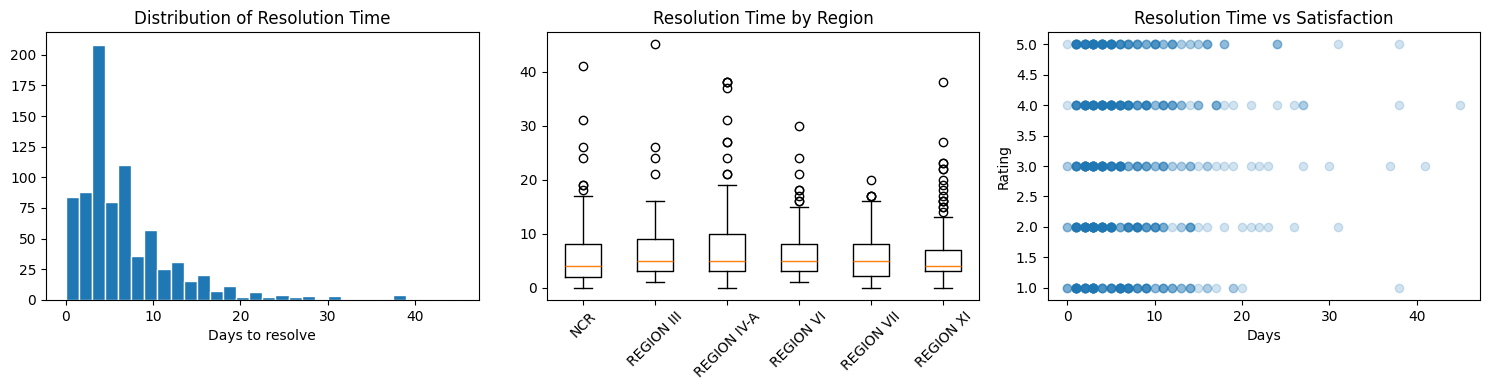

In [41]:
# Lecture 2 demo
import pandas as pd
import matplotlib.pyplot as plt

clean = pd.read_csv("data/service_requests_clean_v1.csv")
days = clean["days_to_resolve"].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(days, bins=30, edgecolor="white")
axes[0].set_title("Distribution of Resolution Time")
axes[0].set_xlabel("Days to resolve")

regions = sorted(clean["region"].unique())
data = [clean[clean["region"] == r]["days_to_resolve"].dropna() for r in regions]
axes[1].boxplot(data, tick_labels=regions)
axes[1].set_title("Resolution Time by Region")
axes[1].tick_params(axis="x", rotation=45)

sub = clean.dropna(subset=["days_to_resolve", "satisfaction_rating"])
axes[2].scatter(sub["days_to_resolve"], sub["satisfaction_rating"], alpha=0.2)
axes[2].set_title("Resolution Time vs Satisfaction")
axes[2].set_xlabel("Days")
axes[2].set_ylabel("Rating")

plt.tight_layout()
plt.show()


### Hands-On 2 — Distributions and Relationships · 11:40–12:40

#### Task 2.1 and 2.2 — Histogram with 20 bins and 60 bins

Create and compare a histogram of `days_to_resolve` using **20 and 60 bins**. Add a descriptive title and axis labels.

In a comment, state which version you would present and why.


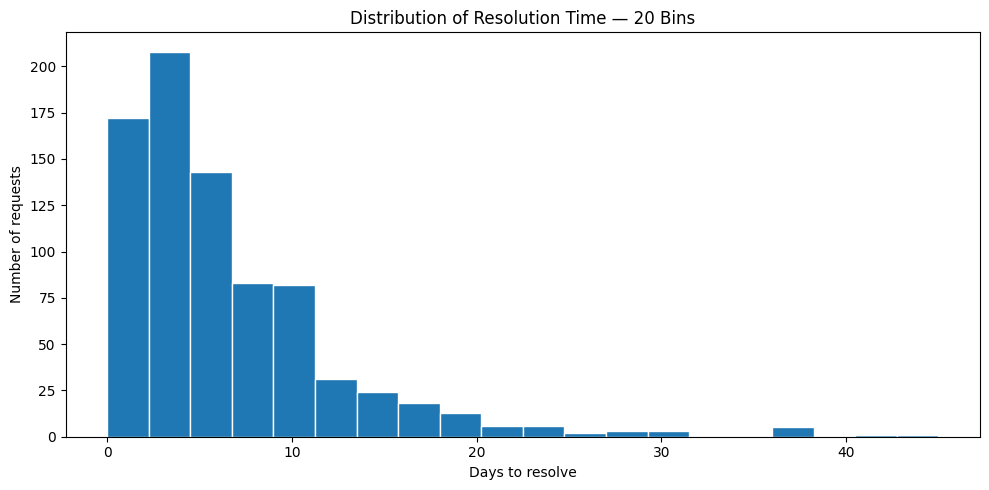

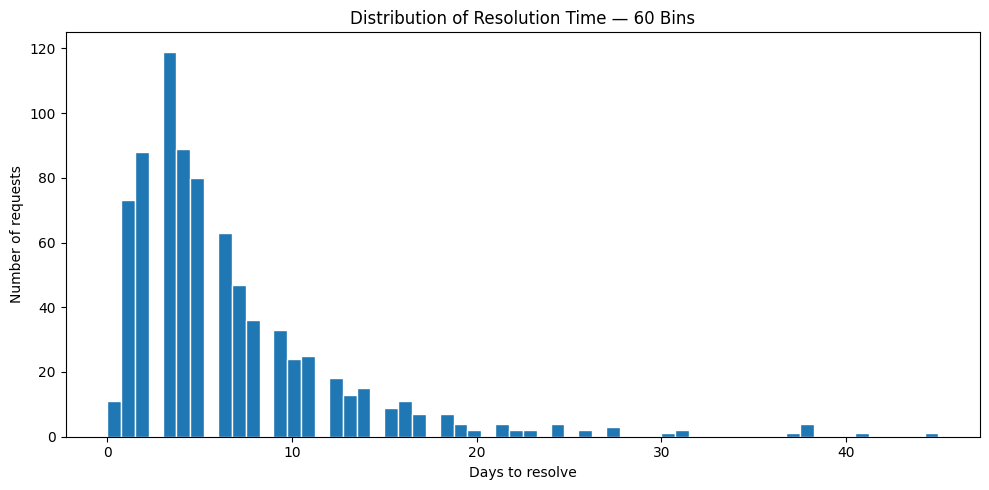

In [42]:
# ============================================================
# HANDS-ON 2 — DISTRIBUTIONS AND RELATIONSHIPS
# Task 2.1 and 2.2 — Compare 20 and 60 Bins
# ============================================================

# STEP 1 — Import the libraries needed for the task.
import pandas as pd
import matplotlib.pyplot as plt


# STEP 2 — Load the cleaned dataset.
clean = pd.read_csv("data/service_requests_clean_v1.csv")


# STEP 3 — Select days_to_resolve and remove missing values.
# Missing values cannot be displayed in the histogram.
days = clean["days_to_resolve"].dropna()


# STEP 4 — Create the 20-bin histogram.
# A smaller number of bins gives a more general view of the distribution.
plt.figure(figsize=(10, 5))

plt.hist(
    days,
    bins=20,
    edgecolor="white"
)

# Add a descriptive title and axis labels.
plt.title("Distribution of Resolution Time — 20 Bins")
plt.xlabel("Days to resolve")
plt.ylabel("Number of requests")

# Adjust spacing and display the chart.
plt.tight_layout()
plt.show()


# STEP 5 — Create the 60-bin histogram.
# More bins provide greater detail but can also make the distribution
# look fragmented or noisy.
plt.figure(figsize=(10, 5))

plt.hist(
    days,
    bins=60,
    edgecolor="white"
)

# Add a descriptive title and axis labels.
plt.title("Distribution of Resolution Time — 60 Bins")
plt.xlabel("Days to resolve")
plt.ylabel("Number of requests")

# Adjust spacing and display the chart.
plt.tight_layout()
plt.show()


# STEP 6 — Choose which version to present.
# Compare the two charts visually before making the final choice.
#
# I would present the 20-bin version because it provides a clearer
# overall view of the distribution while avoiding excessive visual
# fragmentation from very narrow bins.

#### Task 2.3 — Box plot by channel

Create a box plot of `days_to_resolve`, grouped by `channel`.

Label the y-axis in days and give the chart a descriptive title.


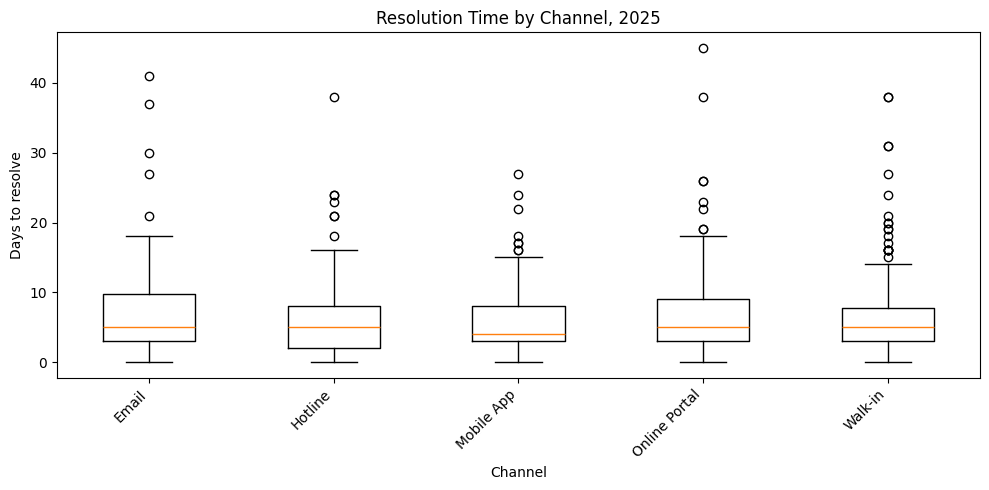

In [43]:
# ============================================================
# TASK 2.3 — BOX PLOT BY CHANNEL
# ============================================================

# STEP 1 — Import the libraries needed for the task.
import pandas as pd
import matplotlib.pyplot as plt


# STEP 2 — Load the cleaned dataset.
clean = pd.read_csv("data/service_requests_clean_v1.csv")


# STEP 3 — Get the unique channels.
channels = sorted(clean["channel"].dropna().unique())


# STEP 4 — Create a separate list of resolution times for each channel.
# Missing days_to_resolve values are removed from each group.
data_by_channel = [
    clean[clean["channel"] == channel]["days_to_resolve"].dropna()
    for channel in channels
]


# STEP 5 — Create the box plot.
plt.figure(figsize=(10, 5))

plt.boxplot(
    data_by_channel,
    tick_labels=channels
)


# STEP 6 — Add a descriptive title.
plt.title("Resolution Time by Channel, 2025")


# STEP 7 — Label the axes.
plt.xlabel("Channel")
plt.ylabel("Days to resolve")


# STEP 8 — Rotate the channel labels for readability.
plt.xticks(rotation=45, ha="right")


# STEP 9 — Adjust spacing.
plt.tight_layout()


# STEP 10 — Display the chart.
plt.show()

#### Task 2.4 — Scatter plot: office staffing and workload

The office master data is nested JSON. Flatten it and merge request counts by `office_code`.

Store the result in `office_load` with at least:
- `office_code`
- `staff_count`
- `request_count`

Then make a scatter plot of `staff_count` against `request_count` and label the points with office codes.

**Important:** there are only nine offices. Treat patterns as observations to discuss, not proof of a staffing policy.


Office Load:
   office_code  staff_count  request_count
0  DICT-NCR-01           38             98
1  DICT-NCR-02            8             98
2   DICT-R3-01           27            201
3  DICT-R4A-01           33            116
4  DICT-R4A-02           38            102
5   DICT-R6-01           34            212
6   DICT-R7-01           16             84
7   DICT-R7-02           33             93
8  DICT-R11-01           21            196


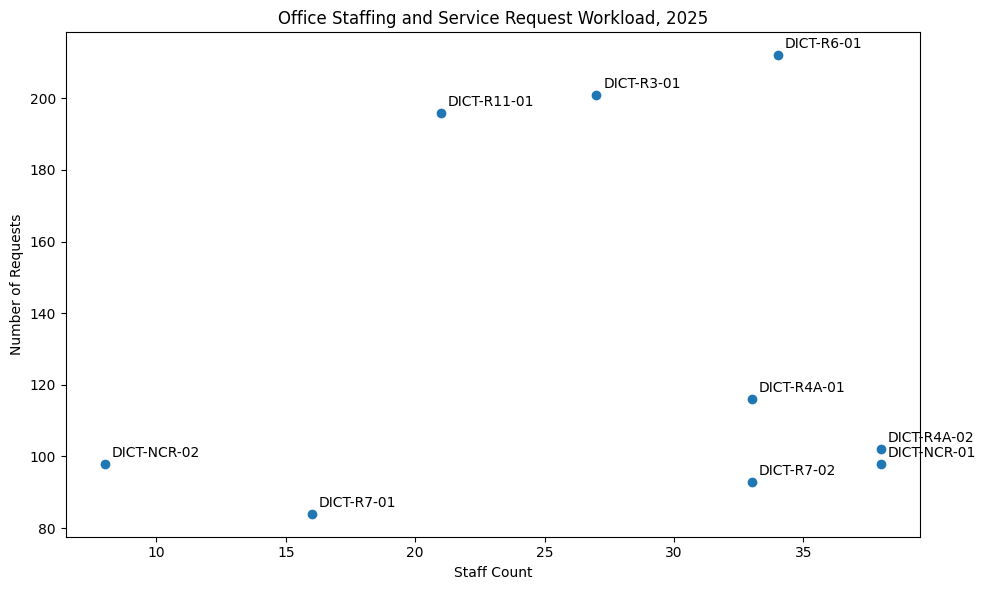

In [44]:
# ============================================================
# TASK 2.4 — SCATTER PLOT: OFFICE STAFFING AND WORKLOAD
# ============================================================

import json
import pandas as pd
import matplotlib.pyplot as plt


# STEP 1 — Load and flatten the nested JSON file.
with open("data/regional_offices.json") as f:
    offices = pd.json_normalize(json.load(f)["offices"])


# STEP 2 — Count the number of service requests for each office.
request_counts = (
    clean.groupby("office_code")
    .size()
    .rename("request_count")
    .reset_index()
)


# STEP 3 — Merge the office master data with the request counts.
# The merge uses office_code as the common key.
office_load = offices[
    ["office_code", "staff_count"]
].merge(
    request_counts,
    on="office_code",
    how="left"
)


# STEP 4 — Display the resulting table.
print("Office Load:")
print(office_load)


# STEP 5 — Create the scatter plot.
plt.figure(figsize=(10, 6))

plt.scatter(
    office_load["staff_count"],
    office_load["request_count"]
)


# STEP 6 — Label each point with its office code.
for _, row in office_load.iterrows():
    plt.annotate(
        row["office_code"],
        (row["staff_count"], row["request_count"]),
        xytext=(5, 5),
        textcoords="offset points"
    )


# STEP 7 — Add a descriptive title.
plt.title("Office Staffing and Service Request Workload, 2025")


# STEP 8 — Label the axes.
plt.xlabel("Staff Count")
plt.ylabel("Number of Requests")


# STEP 9 — Adjust spacing.
plt.tight_layout()


# STEP 10 — Display the scatter plot.
plt.show()


# IMPORTANT:
# There are only nine offices, so any visible pattern should be treated
# as an observation to discuss, not as proof of a staffing policy.

## Check Section 2

The checker focuses on the data preparation behind the visualizations.


In [45]:
# Section 2 checker

def check_section_2():
    required = ["office_load"]
    missing = [x for x in required if x not in globals() or globals()[x] is None]
    if missing:
        print("Missing:", missing)
        return

    checks = {
        "office_load has 9 offices": len(office_load) == 9,
        "staff_count present": "staff_count" in office_load.columns,
        "request_count present": "request_count" in office_load.columns,
        "request counts match clean": office_load.set_index("office_code")["request_count"].sort_index().equals(
            clean.groupby("office_code").size().sort_index().astype(int)
        ),
    }
    for label, ok in checks.items():
        print(("PASS" if ok else "FAIL"), label)

check_section_2()


PASS office_load has 9 offices
PASS staff_count present
PASS request_count present
PASS request counts match clean


# Analysis and Discussion 2

## 1. The 20-bin and 60-bin histograms can tell slightly different stories. Which would you present, and how would you defend the choice?

**Answer:** I would present the **20-bin histogram** because it provides a clearer overall view of the distribution of resolution times. The 60-bin version shows more detail, but it can make normal variation appear fragmented or noisy. I would defend the choice by explaining that the goal is to communicate the overall pattern clearly, while still preserving important features of the data. If the 60-bin chart revealed a meaningful pattern that was hidden by 20 bins, I would consider using it instead.

---

## 2. Are points beyond a box plot’s whiskers automatically errors? What evidence would you want before removing them?

**Answer:** No. Points beyond the whiskers are **potential statistical outliers**, not automatically errors. They may represent legitimate cases that took unusually long to resolve. Before removing them, I would check the original records, data-entry procedures, definitions of `days_to_resolve`, and whether the values are plausible. I would also check whether there is a documented reason for unusually long resolution times. An outlier should only be removed when there is sufficient evidence that it is an error or does not belong in the analysis.

---

## 3. With only nine offices in the staffing/workload scatter, what conclusions are reasonable, and which would be overreach?

**Answer:** With only nine offices, it is reasonable to describe **observed patterns** in the data, such as whether offices with higher staff counts also tend to have higher or lower request counts. We can identify individual offices that appear unusual compared with the others.

It would be an overreach to conclude that staffing levels **cause** workload differences, that a particular staffing policy is effective or ineffective, or that the pattern applies to all offices. The sample is very small, and the scatter plot only shows an association among these nine offices.

---

## 4. How is the scatter between resolution days and satisfaction different from the office staffing scatter in what it can tell us?

**Answer:** The resolution-days versus satisfaction scatter examines the relationship between **two variables at the individual service-request level**. It can help us see whether requests that take longer to resolve tend to have different satisfaction ratings, as well as identify clusters or unusual observations.

The office staffing scatter operates at the **office level**. Each point represents an office and compares its staff count with its total request workload. Therefore, it describes differences among offices rather than relationships among individual requests.

Neither scatter plot by itself establishes causation. They describe associations in the available data and can help identify patterns that may need further investigation.

# Lecture 3 — Design Principles

Good chart design is mostly **subtraction**.

### Do

- Give the chart a descriptive title.
- State the finding only when the data supports it.
- Label axes and include units.
- Use one color unless color has a purpose.
- Sort bars by value unless there is a natural order.
- Start bar axes at zero.
- Remove decorative elements that do not help interpretation.

### Avoid

- 3-D effects that distort comparisons
- rainbow palettes for ordinary categories
- pie charts with too many slices
- legends when direct labels are clearer
- heavy borders and unnecessary gridlines
- truncated bar axes that exaggerate differences

### Accessibility

Never make color the only signal for meaning. A reader should still understand the chart if color discrimination is limited.

### The five-second test

> Can a colleague state the chart’s main point in five seconds without you explaining it?


## Demo — A deliberately poor chart

Run the cell below before redesigning it.


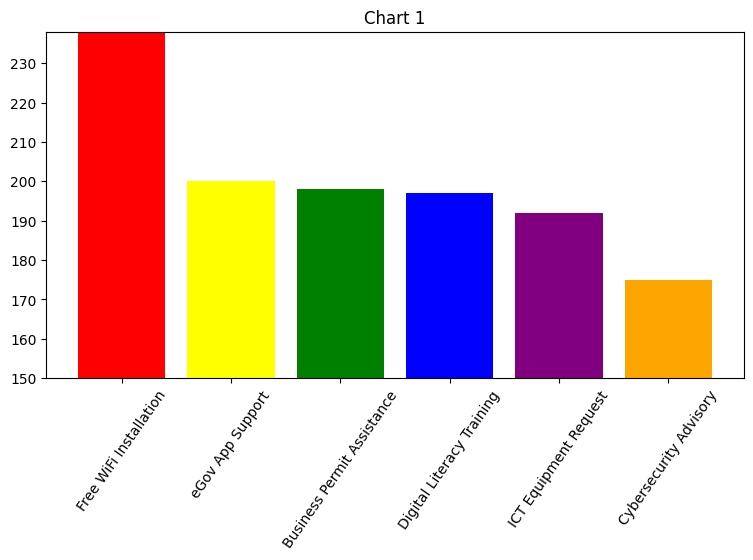

In [46]:
# Poor chart — inspect it before changing anything.
by_service = clean["service_type"].value_counts()

plt.figure(figsize=(9, 4.5))
plt.bar(
    by_service.index,
    by_service.values,
    color=["red", "yellow", "green", "blue", "purple", "orange"],
)
plt.title("Chart 1")
plt.ylim(150, by_service.max())
plt.xticks(rotation=55)
plt.show()


### Hands-On 3 — Redesign a Chart · 3:10–4:10

You are given a deliberately poor chart. Rebuild it properly.

#### Task 3.1 — Diagnose

List at least **three specific problems** with the before chart in comments.


In [47]:
# Task 3.1 — List at least three specific problems.

# 1. The title "Chart 1" is not descriptive and does not tell the reader
#    what is being measured or what the chart is about.

# 2. The chart uses multiple bright colors even though color does not
#    communicate any meaningful category or additional information.

# 3. The y-axis starts at 150 instead of zero, which can exaggerate
#    the differences between the service categories.

# 4. The service types are not sorted by their request counts, making
#    it harder to compare the categories and identify the ranking.

# 5. The x-axis labels are heavily rotated, which makes them harder
#    to read.

# 6. The chart does not clearly identify the y-axis measurement or
#    include an appropriate axis label such as "Number of requests".

#### Task 3.2 — Rebuild it

Create `ordered = by_service.sort_values()` and build a horizontal bar chart that:

- uses a descriptive title;
- labels the axis with units;
- starts at zero;
- uses one main color with one highlight;
- sorts the bars;
- removes unnecessary chart junk.


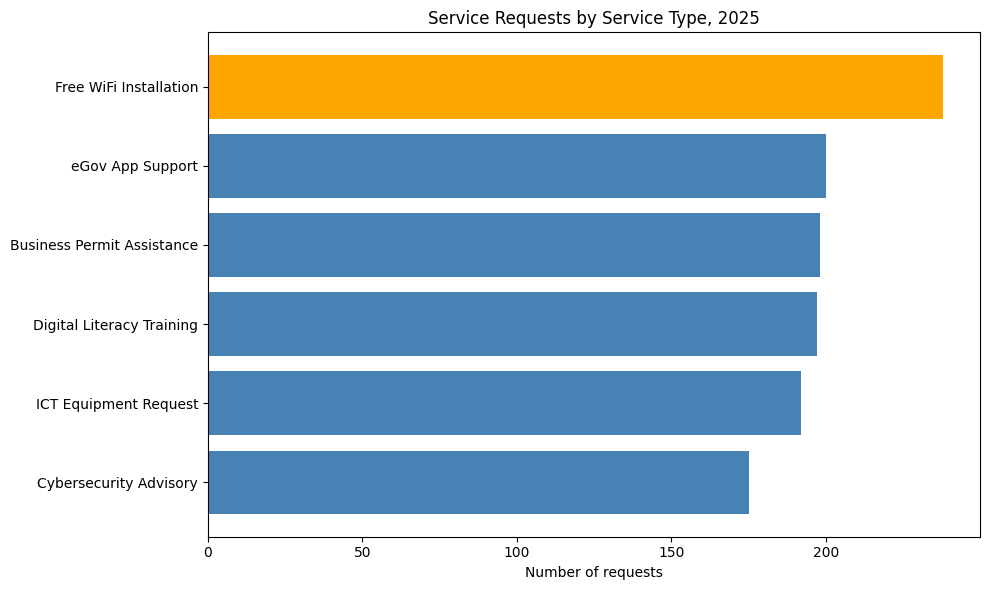

In [48]:
# ============================================================
# TASK 3.2 — REBUILD THE CHART
# ============================================================

# STEP 1 — Sort service types by request count.
# Ascending order works well for a horizontal bar chart because
# the largest value will appear at the top.
ordered = by_service.sort_values()


# STEP 2 — Create the horizontal bar chart.
plt.figure(figsize=(10, 6))

# Use one main color for all bars.
plt.barh(
    ordered.index,
    ordered.values,
    color="steelblue"
)


# STEP 3 — Highlight the service type with the highest number
# of requests using a different color.
# The last bar is the largest because the data is sorted ascending.
plt.barh(
    ordered.index[-1],
    ordered.values[-1],
    color="orange"
)


# STEP 4 — Add a descriptive title.
plt.title("Service Requests by Service Type, 2025")


# STEP 5 — Label the x-axis with its unit.
plt.xlabel("Number of requests")


# STEP 6 — Start the x-axis at zero.
plt.xlim(left=0)


# STEP 7 — Remove unnecessary chart junk.
# No legend is needed because the colors do not represent categories.
plt.grid(False)


# STEP 8 — Adjust spacing so labels are readable.
plt.tight_layout()


# STEP 9 — Display the improved chart.
plt.show()

#### Task 3.3 — Add direct labels and finish

Add the value at the end of each bar and set `redesign_done = True`.


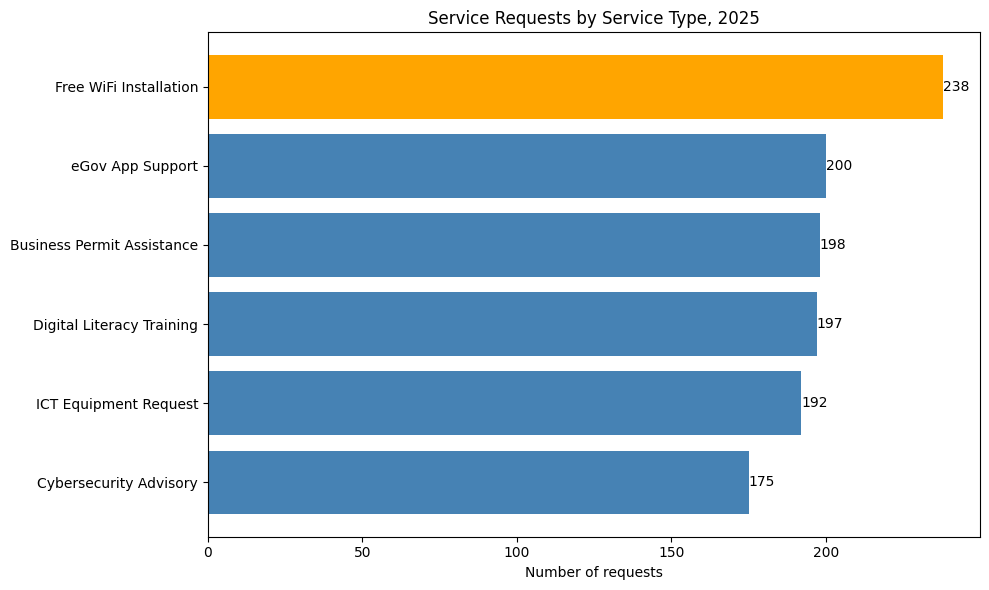

Chart redesign complete: True


In [49]:
# ============================================================
# TASK 3.3 — ADD DIRECT LABELS AND FINISH
# ============================================================

# STEP 1 — Create the improved horizontal bar chart again.
plt.figure(figsize=(10, 6))

plt.barh(
    ordered.index,
    ordered.values,
    color="steelblue"
)

# STEP 2 — Highlight the highest-value bar.
plt.barh(
    ordered.index[-1],
    ordered.values[-1],
    color="orange"
)


# STEP 3 — Add the request count at the end of every bar.
for i, value in enumerate(ordered.values):
    plt.text(
        value,
        i,
        f"{value}",
        va="center",
        ha="left",
        fontsize=10
    )


# STEP 4 — Add a descriptive title.
plt.title("Service Requests by Service Type, 2025")


# STEP 5 — Label the x-axis with units.
plt.xlabel("Number of requests")


# STEP 6 — Start the x-axis at zero.
plt.xlim(left=0)


# STEP 7 — Remove unnecessary chart junk.
plt.grid(False)


# STEP 8 — Adjust spacing for readability.
plt.tight_layout()


# STEP 9 — Display the finished chart.
plt.show()


# STEP 10 — Mark the redesign as complete.
redesign_done = True

print("Chart redesign complete:", redesign_done)

## Check Section 3


In [50]:
# Section 3 checker

def check_section_3():
    required = ["ordered", "redesign_done"]
    missing = [x for x in required if x not in globals() or globals()[x] is None]
    if missing:
        print("Missing:", missing)
        return

    expected = clean["service_type"].value_counts().sort_values()
    checks = {
        "ordered contains the service counts": ordered.equals(expected),
        "redesign_done is True": redesign_done is True,
    }
    for label, ok in checks.items():
        print(("PASS" if ok else "FAIL"), label)

check_section_3()


PASS ordered contains the service counts
PASS redesign_done is True


# Analysis and Discussion 3

## 1. Your new title states a finding. What is the risk of a finding-based title, and how do you keep it honest?

**Answer:** The risk is that a finding-based title can make the chart appear to support a stronger conclusion than the data actually shows. To keep it honest, the title should describe only what the chart directly demonstrates and should include the relevant measure and time period. If the evidence does not support a broader explanation or causal claim, the title should not imply one.

---

## 2. The service counts are fairly close. Does highlighting the top bar overstate the difference?

**Answer:** Yes, it can draw extra attention to a relatively small difference. The highlight should have a clear purpose, such as identifying the highest category, but the reader should still be able to see the actual values and scale. Since the counts are fairly close, direct labels help prevent the color highlight from becoming the main basis for comparison.

---

## 3. Which design rule would you break in a real situation, and what justification would you document?

**Answer:** I might intentionally use more than one color if color communicates a meaningful distinction, such as separating completed and pending requests. I would document why the colors are necessary, what each color represents, and how the chart remains understandable without relying only on color. The exception should improve interpretation rather than simply make the chart more visually attractive.

# Day 8 — Final Checklist

Before publishing a chart, ask:

1. **Question:** What exact question does this chart answer?
2. **Chart:** Is this the simplest chart that answers it?
3. **Scale:** Are the axes honest and complete?
4. **Labels:** Can the reader identify categories and units?
5. **Ordering:** Is the sequence meaningful or intentionally sorted?
6. **Color:** Does color carry meaning, or is it decoration?
7. **Title:** Does the title help the reader understand the point?
8. **Accessibility:** Can the meaning be understood without relying on color alone?
9. **Five seconds:** Can someone state the main point without your narration?

### Reflection

Complete this sentence:

> “The biggest chart-design mistake I will watch for as a trainer is __________ because __________.”


# Day 8 → Day 9 Bridge

**Day 8:** one question → one well-designed chart

**Day 9:** several decision-relevant metrics → dashboard/report

Tomorrow we will combine multiple visuals, choose the metrics that matter, structure the findings as a data story, and prepare the result for publishing and sharing.
